In [31]:
## Comparing the pval library vs the k-cee library — load both
import os, sys, glob, pickle, numpy as np, pandas as pd
from scipy.stats import ttest_ind

REPO = '/grid/koo/home/pmantill/projects/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra'
sys.path.insert(0, os.path.join(REPO, 'eigen-interactions'))
from eigen_steering import EigenMap, ENHANCER_LEN

CT = {'K562': 'K562_v6_do075', 'HepG2': 'HepG2_v6_do03'}

df = pd.read_csv(os.path.join(REPO, 'data', 'joint_library_combined.csv'))
df = df.dropna(subset=['sequence'] + [f'{ct}_log2FC' for ct in CT]).reset_index(drop=True)

em = EigenMap(model_names=CT, device='cpu')
em.load_from_dataframe(df, seq_col='sequence')

raw = np.load(os.path.join(REPO, 'genomic_targets', 'data', 'deeplift_attributions.npz'))
df_full = pd.read_csv(os.path.join(REPO, 'data', 'joint_library_combined.csv'))
seq_valid = df_full['sequence'].notna(); n_full = seq_valid.sum()
keep = df_full.loc[seq_valid, ['sequence'] + [f'{ct}_log2FC' for ct in CT]].notna().all(axis=1).values
del df_full

ohe = em.X.numpy()
for ct in CT:
    hyp = raw[f'attr_{ct}'][:n_full][keep]
    em.attr_hyp[ct] = hyp
    em.attr[ct] = hyp * ohe

# k-cee (target) library
with open(os.path.join(REPO, 'virtual_perturbations/libraries/hippo_target_library.pkl'), 'rb') as f:
    target_lib = pickle.load(f)
kcee_idx = target_lib['df']['seq_idx'].values

# p-val library: Student's t-test on per-replicate log2 ratios; threshold by fold change.
# fc = HepG2 / K562 (linear), derived from mean(log2_ratio) per element.
MPRA_DIR = os.path.join(REPO, 'data/full_joint_mpra')
COLS = ['cell','rep','name','dna','rna','ratio','log2_ratio','n_bc']
def _load(c):
    fs = sorted(glob.glob(f'{MPRA_DIR}/{c}/{c}_rep*.tsv'))
    return pd.concat([pd.read_csv(f, sep='\t', header=None, names=COLS) for f in fs])
hep_w = _load('HepG2').pivot_table(index='name', columns='rep', values='log2_ratio')
k_w   = _load('K562' ).pivot_table(index='name', columns='rep', values='log2_ratio')
shared = hep_w.index.intersection(k_w.index)
H, K = hep_w.loc[shared].values, k_w.loc[shared].values
ok = np.isfinite(H).all(1) & np.isfinite(K).all(1)
_, pv = ttest_ind(H[ok], K[ok], axis=1, equal_var=True)            # Student's t
fc = 2.0 ** (H[ok].mean(1) - K[ok].mean(1))                        # HepG2 / K562
fc_by_name   = dict(zip(shared[ok], fc))
pval_by_name = dict(zip(shared[ok], pv))

fcs   = df['name'].map(fc_by_name).values.astype(float)
pvals = df['name'].map(pval_by_name).values.astype(float)
FC_THRESH = 4.0
pval_idx = np.where(np.isfinite(fcs) & np.isfinite(pvals)
                    & (pvals < 0.05) & ((fcs > FC_THRESH) | (fcs < 1.0 / FC_THRESH)))[0]

print(f'k-cee lib: {len(kcee_idx)} seqs   |   p-val lib: {len(pval_idx)} seqs '
      f'(Student t, p<0.05 & FC>{FC_THRESH:g}x either way)')


EigenMap: ['K562', 'HepG2'], models={'K562': 'K562_v6_do075', 'HepG2': 'HepG2_v6_do03'}
Loaded 56975 sequences, X shape: torch.Size([56975, 4, 281])
k-cee lib: 1059 seqs   |   p-val lib: 957 seqs (Student t, p<0.05 & FC>4x either way)


In [32]:
## Full TF-MoDISco on enhancer (first 230bp) for each library × cell type.
## Uses modisco-lite default hyperparams. Cache key = ENH only.
import h5py
from types import SimpleNamespace
import modiscolite
from modiscolite.tfmodisco import TFMoDISco
from modiscolite.io import save_hdf5

ENH = ENHANCER_LEN  # 230
OUT_DIR = os.path.join(REPO, 'genomic_targets/data/modisco')
os.makedirs(OUT_DIR, exist_ok=True)
HP_TAG = f'enh{ENH}_default'
print(f'tag: {HP_TAG}   (TFMoDISco defaults)')

def load_patterns(h5_path, group):
    if not os.path.exists(h5_path): return []
    out = []
    with h5py.File(h5_path, 'r') as f:
        if group not in f: return []
        names = sorted(f[group].keys(), key=lambda s: int(s.split('_')[-1]))
        for nm in names:
            g = f[group][nm]
            seqlets = [SimpleNamespace(example_idx=int(e))
                       for e in g['seqlets']['example_idx'][...]]
            out.append(SimpleNamespace(
                contrib_scores=g['contrib_scores'][...],
                seqlets=seqlets,
            ))
    return out

def run_or_load(lib, ct, idx):
    h5 = os.path.join(OUT_DIR, f'{lib}_{ct}_{HP_TAG}.h5')
    if os.path.exists(h5):
        pos = load_patterns(h5, 'pos_patterns')
        neg = load_patterns(h5, 'neg_patterns')
        print(f'{lib:5s} {ct:5s}  cached  pos={len(pos)} neg={len(neg)}  -> {os.path.basename(h5)}')
        return pos, neg, h5
    hyp = em.attr_hyp[ct][idx, :, :ENH].transpose(0, 2, 1).astype(np.float32)
    oh  = ohe[idx, :, :ENH].transpose(0, 2, 1).astype(np.float32)
    pos, neg = TFMoDISco(hypothetical_contribs=hyp, one_hot=oh)   # all defaults
    save_hdf5(h5, pos, neg, window_size=21)                       # default sliding_window_size
    print(f'{lib:5s} {ct:5s}  ran     pos={len(pos or [])} neg={len(neg or [])}  -> {os.path.basename(h5)}')
    return load_patterns(h5, 'pos_patterns'), load_patterns(h5, 'neg_patterns'), h5

LIBS = {'kcee': kcee_idx, 'pval': pval_idx}
results = {(lib, ct): run_or_load(lib, ct, idx) for lib, idx in LIBS.items() for ct in CT}


tag: enh230_default   (TFMoDISco defaults)
kcee  K562   cached  pos=7 neg=2  -> kcee_K562_enh230_default.h5
kcee  HepG2  cached  pos=4 neg=1  -> kcee_HepG2_enh230_default.h5
pval  K562   cached  pos=5 neg=0  -> pval_K562_enh230_default.h5
pval  HepG2  cached  pos=5 neg=0  -> pval_HepG2_enh230_default.h5


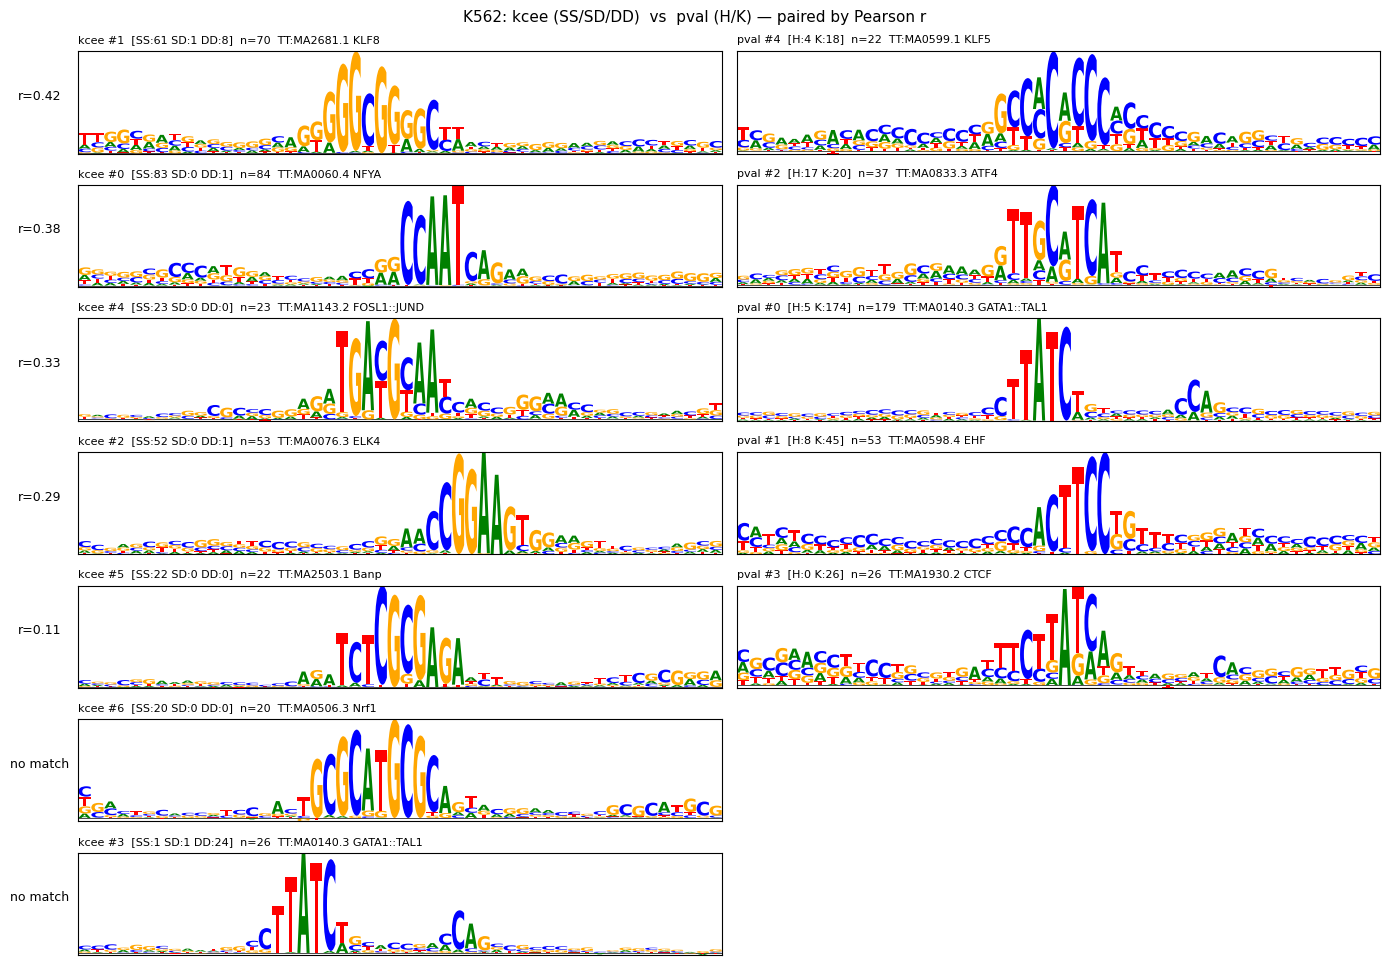

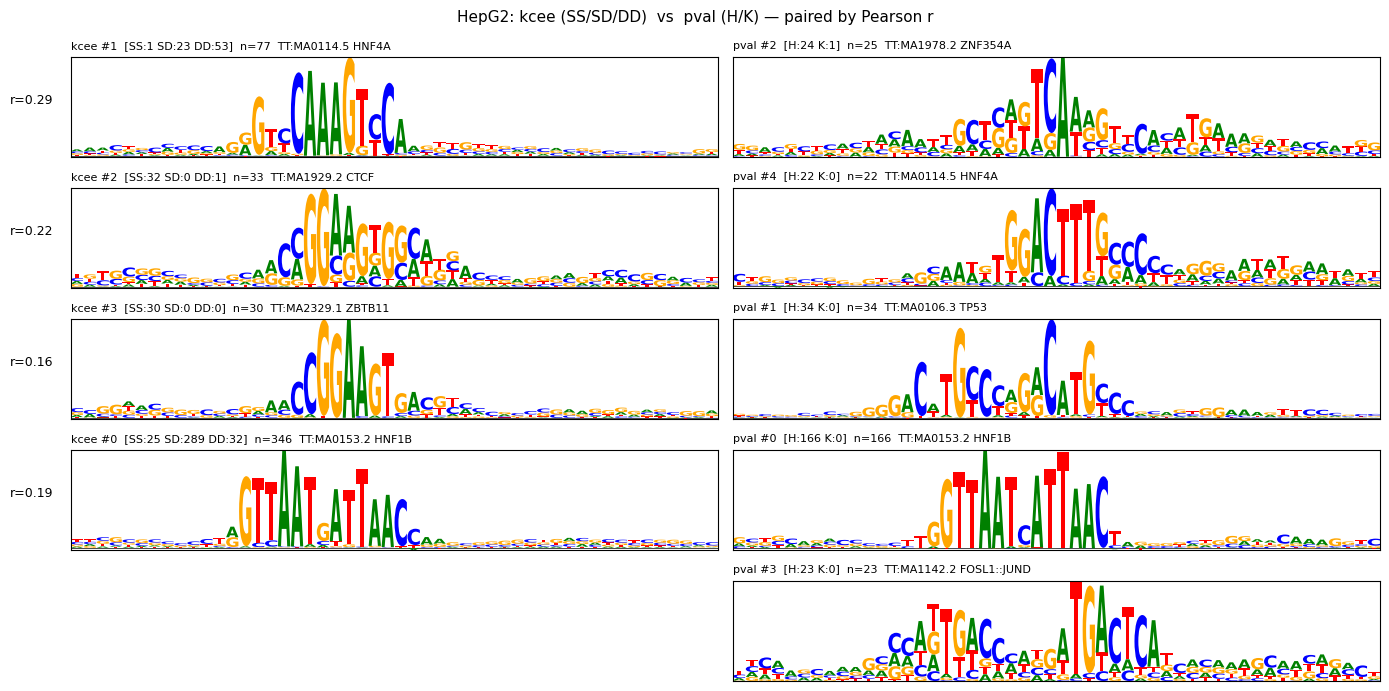

In [33]:
## Side-by-side: kcee vs pval positive motifs per cell type.
## Match across libs by max Pearson r over all shifts + rev-comp.
## Annotate w/ top TOMTOM-lite match (JASPAR2026 vert) + per-category seqlet breakdown.
##   kcee: same-same / same-diff / diff-diff   (SS / SD / DD)
##   pval: HepG2-up  / K562-up                 (H  / K)
%matplotlib inline
import logomaker as lm
import matplotlib.pyplot as plt
from IPython.display import display
from modiscolite import report as mr

MEME_DB = os.path.join(REPO, 'eigen-interactions/motif_db/JASPAR2026_vertebrates.meme')

KCEE_TAG = {'same-same': 'SS', 'same-diff': 'SD', 'diff-diff': 'DD'}
kcee_cat = target_lib['df']['condition'].map(KCEE_TAG).fillna('?').values
pval_cat = np.where(fcs[pval_idx] > FC_THRESH, 'H', 'K')
CATS = {'kcee': (kcee_cat, ['SS', 'SD', 'DD']),
        'pval': (pval_cat, ['H', 'K'])}

def cat_breakdown(p, lib):
    cats, order = CATS[lib]
    ex = np.array([s.example_idx for s in p.seqlets])
    return ' '.join(f'{c}:{int((cats[ex] == c).sum())}' for c in order)

def top1_tomtom(h5):
    d = mr.tomtomlite_dataframe(
        modisco_h5py=h5, output_dir=os.path.dirname(h5),
        meme_motif_db=MEME_DB, pattern_groups=['pos_patterns'], top_n_matches=1)
    return {int(k): str(v) for k, v in d['match0'].items()}

tomtom = {(lib, ct): top1_tomtom(h5) for (lib, ct), (_, _, h5) in results.items()}

def maxr(a, b):
    rc = lambda x: x[::-1, ::-1]
    best = -np.inf
    for bb in (b, rc(b)):
        s, l = (a, bb) if a.shape[0] <= bb.shape[0] else (bb, a)
        for i in range(l.shape[0] - s.shape[0] + 1):
            r = np.corrcoef(s.ravel(), l[i:i+s.shape[0]].ravel())[0, 1]
            if r > best: best = r
    return best

def greedy_match(A, B):
    if not A and not B: return []
    rs = np.array([[maxr(np.asarray(a.contrib_scores), np.asarray(b.contrib_scores))
                    for b in B] for a in A]) if (A and B) else np.zeros((len(A), max(len(B), 1)))
    paired_b, out = set(), []
    order = sorted(range(len(A)), key=lambda i: -(rs[i].max() if len(B) else -1))
    for i in order:
        if not B:
            out.append((i, None, np.nan)); continue
        cand = [int(j) for j in np.argsort(-rs[i]) if int(j) not in paired_b]
        if not cand:
            out.append((i, None, np.nan))
        else:
            j = cand[0]; paired_b.add(j); out.append((i, j, float(rs[i, j])))
    for j in range(len(B)):
        if j not in paired_b: out.append((None, j, np.nan))
    return out

def logo(ax, p, label):
    cwm = np.asarray(p.contrib_scores, dtype=float)
    lm.Logo(pd.DataFrame(cwm, columns=list('ACGT')), ax=ax)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(label, fontsize=8, loc='left')

for ct in CT:
    A = results[('kcee', ct)][0]
    B = results[('pval', ct)][0]
    pairs = greedy_match(A, B)
    n_rows = max(len(pairs), 1)
    fig, axes = plt.subplots(n_rows, 2, figsize=(14, 1.4 * n_rows), squeeze=False)
    for row, (i, j, r) in enumerate(pairs):
        ax_l, ax_r = axes[row]
        if i is not None:
            logo(ax_l, A[i],
                 f'kcee #{i}  [{cat_breakdown(A[i], "kcee")}]  '
                 f'n={len(A[i].seqlets)}  TT:{tomtom[("kcee", ct)].get(i, "-")}')
        else:
            ax_l.axis('off')
        if j is not None:
            logo(ax_r, B[j],
                 f'pval #{j}  [{cat_breakdown(B[j], "pval")}]  '
                 f'n={len(B[j].seqlets)}  TT:{tomtom[("pval", ct)].get(j, "-")}')
        else:
            ax_r.axis('off')
        rtxt = f'r={r:.2f}' if np.isfinite(r) else 'no match'
        axes[row, 0].set_ylabel(rtxt, rotation=0, labelpad=28, fontsize=9)
    fig.suptitle(f'{ct}: kcee (SS/SD/DD)  vs  pval (H/K) — paired by Pearson r', fontsize=11)
    fig.tight_layout(); display(fig); plt.close(fig)


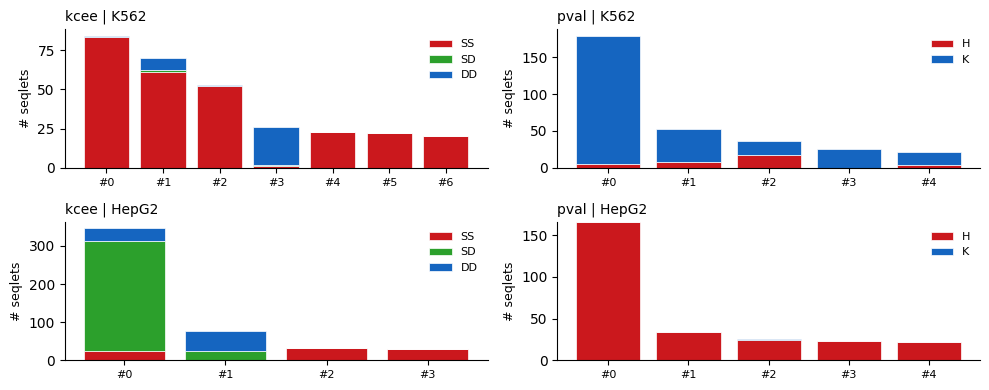

In [34]:
## Barplot: per-pattern seqlet counts, stacked by category. kcee | pval, one row per ct.
COLORS = {'SS': '#cb181d', 'SD': '#2ca02c', 'DD': '#1565C0',
          'H':  '#cb181d', 'K':  '#1565C0'}

fig, axes = plt.subplots(len(CT), 2, figsize=(10, 2 * len(CT)), squeeze=False)
for r, ct in enumerate(CT):
    for c, lib in enumerate(['kcee', 'pval']):
        ax = axes[r, c]
        pats = results[(lib, ct)][0]
        cats, order = CATS[lib]
        x = np.arange(len(pats))
        bottom = np.zeros(len(pats))
        for cname in order:
            counts = np.array([
                int((cats[np.array([s.example_idx for s in p.seqlets])] == cname).sum())
                for p in pats
            ]) if pats else np.array([])
            ax.bar(x, counts, bottom=bottom, color=COLORS[cname], label=cname,
                   edgecolor='white', linewidth=0.5)
            bottom += counts
        ax.set_xticks(x); ax.set_xticklabels([f'#{i}' for i in x], fontsize=8)
        ax.set_ylabel('# seqlets', fontsize=9)
        ax.set_title(f'{lib} | {ct}', fontsize=10, loc='left')
        ax.legend(fontsize=8, frameon=False)
        for sp in ('top', 'right'): ax.spines[sp].set_visible(False)
plt.tight_layout(); plt.show()
